# Customer Pulse — NPS, satisfaction, branding

**The study.** A short, branded customer-satisfaction survey for three customer segments: a Net Promoter question, an attribute matrix, a preferred-channel question, a ranking of priorities and one open question. The client wants their colours and logo, a pilot behind an access code, a kiosk version that runs offline, and an Excel banner plus a report.

**This directory:** `survey.py` (codebook + questionnaire + `options` + the `UIConfig` theme in one file), `build_bundle.py` (a self-contained HTML bundle), `analysis.py` (sentinel cleanup, NPS, deliverables, combined report). The notebook imports them.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))          # make the study modules importable from any launcher

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

import siamang as sg
from siamang.reporting.tables import CrossTable, FreqTable, GroupMeanTable
import dataclasses
from siamang.frontend import compile_css

# Jupyter renders SurveyTable objects as HTML; make the text/plain fallback (text-only viewers,
# nbconvert --to script) show the Markdown table with its statistics footer instead of the dataclass repr.
for _cls in (FreqTable, CrossTable, GroupMeanTable):
    get_ipython().display_formatter.formatters["text/plain"].for_type(_cls, lambda t, p, cycle: p.text(t.to_markdown()))
OUT = Path("out"); OUT.mkdir(exist_ok=True)
print("siamang", sg.__version__, "| working directory:", Path.cwd().name)

siamang 0.6.0 | working directory: customer_pulse


## 1. One file: codebook, questionnaire, options, theme in survey.py

`other_specify=True` and `none_of_above=True` store **strings** rather than codes (`{"code": "__other__", "text": ...}`, `"__none__"`); `na_option="Not used"` on the Matrix stores `"na"`. `UIConfig` is frozen — start from `get_preset()` and use `dataclasses.replace()`; enumerated fields are validated at construction.

In [2]:
print(Path("survey.py").read_text())

"""Customer Pulse — a branded NPS / satisfaction survey in one file."""

import dataclasses

import siamang as sg
from siamang.core import ContentPage, FinalPage
from siamang.frontend import get_preset

AGREE5 = {1: "Very poor", 2: "Poor", 3: "Fair", 4: "Good", 5: "Excellent"}

# ── Codebook ─────────────────────────────────────────────────────────────────
customer_type = sg.Variable("customer_type", scale="nominal", label="Customer type",
                            labels={1: "New (under 1 year)", 2: "Returning", 3: "Business account"})
product = sg.Variable("product", scale="nominal", label="Product used most",
                      labels={1: "Web app", 2: "Mobile app", 3: "API", 99: "Other"})
nps = sg.Variable("nps", scale="interval", label="Likelihood to recommend (0-10)",
                  dtype="int", valid_range=(0, 10))
attr_price = sg.Variable("attr_price", scale="ordinal", label="Value for money", labels=AGREE5)
attr_quality = sg.Variable("attr_quality", scale="ordinal", la

In [3]:
from survey import ATTRIBUTES, channel_pref, nps, options, priorities, survey, ui

survey.validate(strict=True)
print("strict lint:", [w.code for w in survey.lint(level="strict")] or "clean", "|", len(survey.all_questions()), "questions")
css = compile_css(ui)
print(len(css), "bytes of CSS; primary colour present:", "#0f766e" in css, "| logo text:", ui.effective_logo_text)
try:                                                   # demonstration: a typo in an enumerated field
    sg.UIConfig(question_style="card")
except ValueError as e:
    print("EXPECTED (demonstration) — UIConfig validates its fields at construction:", e)

strict lint: clean | 9 questions
10207 bytes of CSS; primary colour present: True | logo text: AA
EXPECTED (demonstration) — UIConfig validates its fields at construction: question_style must be one of: ['accent', 'carded', 'divided', 'plain'].


In [4]:
!PYTHONPATH=. siamang validate survey.py --strict; echo "exit code: $?   (0 = valid)"

OK — no warnings.


exit code: 0   (0 = valid)


## 2. A self-contained bundle for kiosks: build_bundle.py

`survey.deploy()` publishes to a host; for an offline kiosk you only need the static files, built with the same machinery `deploy()` uses (`ReactRuntime` needs the live questionnaire via `survey=`).

In [5]:
print(Path("build_bundle.py").read_text())

"""Build a self-contained HTML bundle (kiosk / offline use) without deploying."""

from pathlib import Path

from siamang.frontend import (
    ClientEnv, FrontendBuilder, LocalClientTemplate, ReactRuntime, compile_css,
    compile_questionnaire,
)

from survey import options, survey, ui

schema = compile_questionnaire(survey, options=options)
builder = FrontendBuilder(runtime=ReactRuntime(), ui=ui)      # ReactRuntime: routing + scripts
bundle = builder.build(
    schema,
    client=LocalClientTemplate(),                              # POSTs to /responses of the host
    env=ClientEnv(survey_id="kiosk-2026", backend="local", settings={}),
    survey=survey,                                             # the React runtime needs it
)
target = Path("out/bundle")
bundle.write_to(target)
print(sorted(p.name for p in target.iterdir()))
print("digest:", bundle.compute_digest())
print("css bytes:", len(compile_css(ui)))                       # inspect the compiled theme



In [6]:
!PYTHONPATH=. python build_bundle.py

['bundle.1e28ce94.js', 'closed.html', 'env.1e28ce94.js', 'index.html', 'manifest.json', 'style.1e28ce94.css', 'vendor']
digest: c286bf6ea436b077
css bytes: 10207


## 3. Local deploy loop and the sentinel answers

Deploy locally with the theme, submit two responses the way the browser does — including `"na"`, an "Other" dict and `"__none__"` — and see what comes back.

In [7]:
result = survey.deploy(backend_kwargs={"path": str(OUT / "pulse.db")}, frontend_kwargs={"host": "127.0.0.1"}, ui=ui, **options)
for answers in [
    {"customer_type": 1, "product": {"code": "__other__", "text": "Desktop client"}, "nps": 9,
     "matrix_attr_price": {"attr_price": 4, "attr_quality": 5, "attr_support": "na", "attr_speed": 4},
     "overall_sat": 5, "channel_pref": "__none__", "priorities": [2, 5, 3], "comment": "Faster exports please.",
     "contact_ok": 1, "__options__": {}, "__pages__": [], "__errors__": {}},
    {"customer_type": 3, "product": 3, "nps": 6,
     "matrix_attr_price": {"attr_price": 3, "attr_quality": 4, "attr_support": 2, "attr_speed": 3},
     "overall_sat": 3, "channel_pref": 1, "priorities": [3, 1, 4], "contact_ok": 2,
     "__options__": {}, "__pages__": [], "__errors__": {}},
]:
    print(requests.post(f"{result.url}/responses", json={"survey_id": result.survey_id, "responses": answers}, timeout=5).json())
raw = result.collect(); result.frontend_ref.stop()
raw[["product", "matrix_attr_price", "channel_pref", "priorities"]]

{'ok': True, 'response_id': 1}
{'ok': True, 'response_id': 2}


,product,matrix_attr_price,channel_pref,priorities
0,"{'code': '__other__', 'text': 'Desktop client'}","{'attr_price': 4, 'attr_quality': 5, 'attr_sup...",__none__,"[2, 5, 3]"
1,3,"{'attr_price': 3, 'attr_quality': 4, 'attr_sup...",1,"[3, 1, 4]"


| Runtime feature | Stored value | Cleanup |
| :--- | :--- | :--- |
| `Matrix` / `LikertScale` with `na_option` | the string `"na"` | `replace("na", np.nan)` then `pd.to_numeric` |
| `SingleChoice(other_specify=True)` | `{"code": "__other__", "text": "..."}` | map to a declared code (99), keep the text in its own column |
| `SingleChoice(none_of_above=True)` | the string `"__none__"` | replace with a code and register its label with `dataclasses.replace(var, labels=...)` |

## 4. Analysis step by step: analysis.py

Synthetic data with a few sentinels injected (`simulate()` never produces them), then NPS groups via `recode()` / `derive()`, attributes, ranking tables.

In [8]:
print(Path("analysis.py").read_text())

"""Customer Pulse — NPS analysis, client deliverables, combined report."""

import dataclasses
from pathlib import Path

import numpy as np
import pandas as pd

import siamang as sg
from survey import ATTRIBUTES, channel_pref, priorities, product, survey

OUT = Path("out")
OUT.mkdir(exist_ok=True)

data = survey.simulate(n=600, seed=7)
frame = data.frame

# ── 1. Rehearse the sentinel cleanup real data will need ──────────────────────
# (simulate() never produces them, so inject a few for the rehearsal)
frame = frame.astype({"attr_support": object, "product": object, "channel_pref": object})
frame.loc[frame.sample(30, random_state=1).index, "attr_support"] = "na"      # Matrix "Not used"
frame.loc[frame.sample(20, random_state=2).index, "product"] = [
    {"code": "__other__", "text": "Desktop client"}] * 20                     # other_specify
frame.loc[frame.sample(25, random_state=3).index, "channel_pref"] = "__none__"  # none_of_above

attr_cols = [v.name for v in ATTRIBUTES]
clean 

In [9]:
data = survey.simulate(n=600, seed=7)
frame = data.frame.astype({"attr_support": object, "product": object, "channel_pref": object})
frame.loc[frame.sample(30, random_state=1).index, "attr_support"] = "na"
frame.loc[frame.sample(20, random_state=2).index, "product"] = [{"code": "__other__", "text": "Desktop client"}] * 20
frame.loc[frame.sample(25, random_state=3).index, "channel_pref"] = "__none__"

attr_cols = [v.name for v in ATTRIBUTES]
clean = frame.copy()
clean[attr_cols] = clean[attr_cols].replace("na", np.nan).apply(pd.to_numeric)
is_other = clean["product"].map(lambda v: isinstance(v, dict))
clean["product_other"] = clean.loc[is_other, "product"].map(lambda d: d["text"])
clean["product"] = clean["product"].map(lambda v: 99 if isinstance(v, dict) else v)
clean["channel_pref"] = clean["channel_pref"].replace("__none__", 0)
data = data.with_frame(clean)
data.variables["channel_pref"] = dataclasses.replace(channel_pref, labels={0: "None of these", **channel_pref.labels})
data.variables.add(sg.Variable("product_other", scale="nominal", label="Other product (verbatim)"))
print("errors after cleanup:", [i.code for i in data.validate() if i.severity == "error"] or "none")

data = data.recode("nps", into="nps_group", bins=[0, 7, 9, 11],
                   labels=["Detractor (0-6)", "Passive (7-8)", "Promoter (9-10)"], label="NPS group")
data = data.derive(name="is_promoter", expression=nps.ge(9), label="Promoter", labels={0: "No", 1: "Yes"})
data = data.derive(name="is_detractor", expression=nps.le(6), label="Detractor", labels={0: "No", 1: "Yes"})
share = data.frame[["is_promoter", "is_detractor"]].mean() * 100
nps_score = round(share["is_promoter"] - share["is_detractor"], 1)
print(f"NPS = {nps_score:+}", "|", data.analysis.proportion_ci("is_promoter", value=1))
data.report.freq("nps_group")

errors after cleanup: none
NPS = -49.2 | {'p': 0.17666666666666667, 'lower': 0.14614996285526055, 'upper': 0.20718337047807278, 'n': 600.0}


Value,Label,N,%,Cumulative %
1,Detractor (0-6),401,66.8,66.8
2,Passive (7-8),93,15.5,82.3
3,Promoter (9-10),106,17.7,100.0
,Total,600,100.0,100.0


In [10]:
data.report.crosstab('customer_type', 'nps_group', pct='row')

Customer type,Detractor (0-6),Passive (7-8),Promoter (9-10),Total
New (under 1 year),72.5,12.3,15.2,204
Returning,62.3,18.1,19.6,199
Business account,65.5,16.2,18.3,197
Total,401.0,93.0,106.0,600


In [11]:
data.report.means('nps', by='customer_type')      # interval, 3 groups → ANOVA

Customer type,Mean,SD,Median,N
New (under 1 year),4.539,3.049,4.0,204
Returning,5.101,3.186,5.0,199
Business account,4.980,3.100,5.0,197


In [12]:
seg = data.frame.groupby("customer_type")[["is_promoter", "is_detractor"]].mean() * 100
seg["nps"] = (seg["is_promoter"] - seg["is_detractor"]).round(1)
seg.index = seg.index.map(data.variables["customer_type"].labels)
display(seg.round(1))
print("alpha (attributes):", round(data.scale_alpha(attr_cols), 3), "(≈ 0 on uniform synthetic data — expected)")
data = data.create_index("attr_index", items=attr_cols, method="mean", label="Attribute index")
print(data.analysis.spearman("attr_index", "nps"))
ranks = data.frame["priorities"].dropna()
top = pd.DataFrame({"ranked_first_%": ranks.map(lambda r: r[0] if r else None).value_counts(normalize=True) * 100,
                    "in_top3_%": ranks.explode().value_counts() / len(ranks) * 100}).round(1)
top.index = top.index.map(priorities.labels)
top.sort_values("ranked_first_%", ascending=False)

,is_promoter,is_detractor,nps
customer_type,,,
New (under 1 year),15.2,72.5,-57.4
Returning,19.6,62.3,-42.7
Business account,18.3,65.5,-47.2


alpha (attributes): -0.045 (≈ 0 on uniform synthetic data — expected)
{'rho': -0.007754817158235168, 'p_value': 0.8496537892399083, 'n': 600.0}


,ranked_first_%,in_top3_%
priorities,,
More features,20.8,44.2
Better support,20.8,39.3
Faster delivery,20.7,42.2
Better documentation,19.5,37.3
Lower price,18.2,38.3


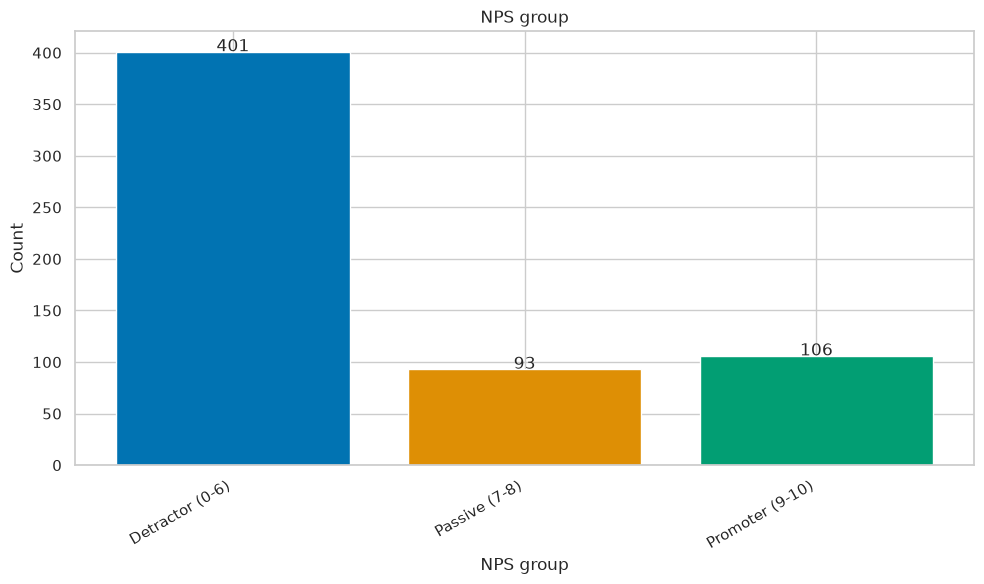

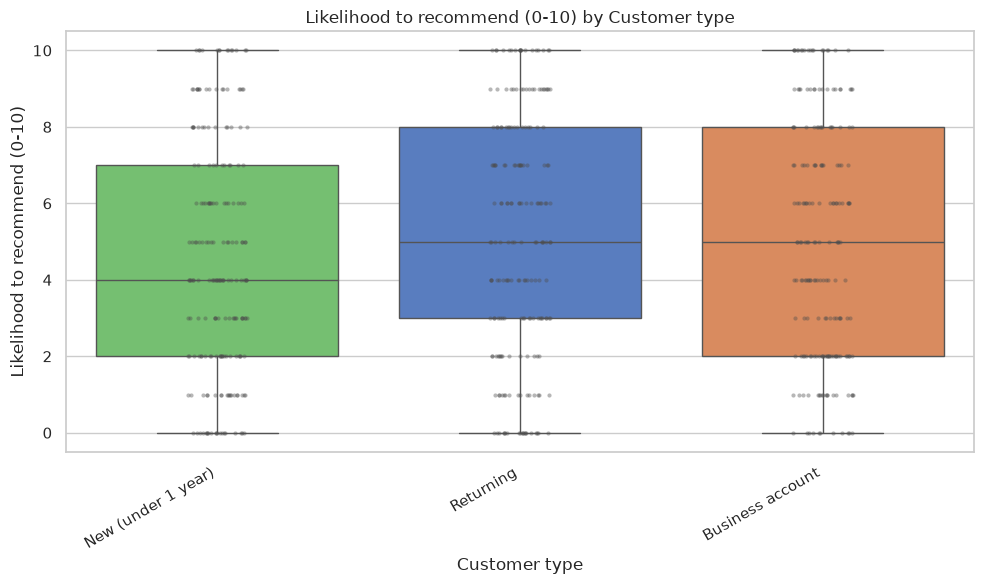

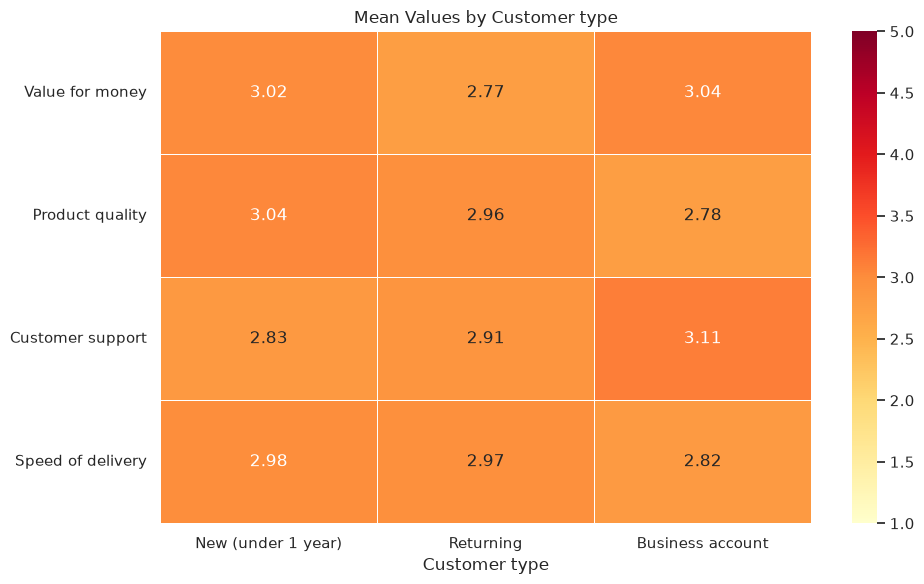

In [13]:
data.plot.bar("nps_group", palette="colorblind").plot(); plt.show()
data.plot.boxplot("nps", by="customer_type", show_points=True).plot(); plt.show()
data.plot.heatmap(attr_cols, by="customer_type", vmin=1, vmax=5).plot(); plt.show()

## 5. Deliverables from the script

`analysis.py` writes the banner and Excel tables, the PNGs and the combined report (`Report.combine()` keeps "Sample", "Findings" and "Verbatims" as sections with a contents list).

In [14]:
!PYTHONPATH=. python analysis.py 2>&1 | tail -3

Better documentation            19.5       37.3
Lower price                     18.2       38.3
['bundle', 'fig_8.png', 'nps_by_type.png', 'nps_by_type.xlsx', 'nps_groups.png', 'pulse.db', 'pulse_banner.xlsx', 'pulse_report.html', 'pulse_report.md']


In [15]:
print(Path("out/pulse_report.md").read_text()[:1200])

# Customer Pulse 2026 — report

## Contents
- [Sample](#sample)
- [Findings](#findings)
- [Verbatims](#verbatims)

## Sample

**Completed interviews:** 600

*Customer type*

| Value | Label | N | % | Cumulative % |
|---|---|---|---|---|
| 1 | New (under 1 year) | 204 | 34.0 | 34.0 |
| 2 | Returning | 199 | 33.2 | 67.2 |
| 3 | Business account | 197 | 32.8 | 100.0 |
|  | Total | 600 | 100.0 | 100.0 |

Variable = Customer type; N valid = 600

## Findings

*Net Promoter Score and drivers*

**NPS:** -49.2

*Table 1. NPS by segment*

| Customer type | Mean | SD | Median | N |
|---|---|---|---|---|
| New (under 1 year) | 4.539 | 3.049 | 4.0 | 204 |
| Returning | 5.101 | 3.186 | 5.0 | 199 |
| Business account | 4.98 | 3.1 | 5.0 | 197 |

F = 1.8210; p = 0.1628; N = 600; Variable = Likelihood to recommend (0-10)

![Figure 1. Attribute ratings by segment](fig_8.png)

*Figure 1. Attribute ratings by segment*

*Table 2. Promoters, detractors and NPS by segment*

|   is_promoter |   is_detractor | 